
[INFO] Loading model from output/best_model.pth...

[INFO] Evaluating towards-model-2 with input_type=y-profile...
Built transform with input_type=y-profile, scaling=enabled
Built target transform with target_type=raw, scaling=enabled
label_names: ['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs', 'y-local', 'pt', 'cotAlpha', 'cotBeta', 'y-midplane', 'x-midplane']


100%|██████████| 79/79 [00:00<00:00, 88.72it/s] 


[METRIC] towards-model-2 accuracy: 0.376900
[METRIC] towards-model-2 high-vs-low AUC: 0.681755


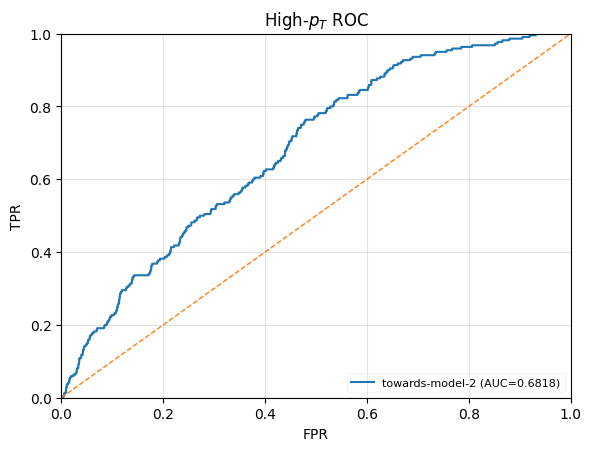

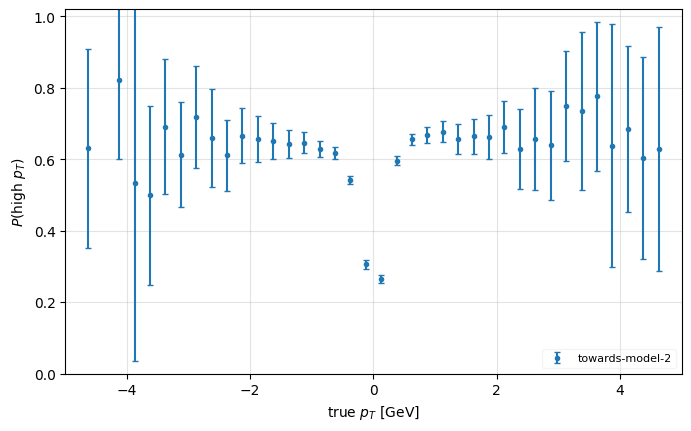

Bin 0: true pt in [-5.00, -4.50), acceptance: 1.0000 (3/3)
Bin 1: true pt in [-4.50, -4.00), acceptance: 1.0000 (3/3)
Bin 2: true pt in [-4.00, -3.50), acceptance: 0.8000 (4/5)
Bin 3: true pt in [-3.50, -3.00), acceptance: 0.8824 (15/17)
Bin 4: true pt in [-3.00, -2.50), acceptance: 0.8636 (19/22)
Bin 5: true pt in [-2.50, -2.00), acceptance: 0.8387 (52/62)
Bin 6: true pt in [-2.00, -1.80), acceptance: 0.8182 (36/44)
Bin 7: true pt in [-1.80, -1.60), acceptance: 0.7586 (44/58)
Bin 8: true pt in [-1.60, -1.40), acceptance: 0.8679 (92/106)
Bin 9: true pt in [-1.40, -1.20), acceptance: 0.8682 (112/129)
Bin 10: true pt in [-1.20, -1.00), acceptance: 0.8287 (179/216)
Bin 11: true pt in [-1.00, -0.80), acceptance: 0.7963 (258/324)
Bin 12: true pt in [-0.80, -0.60), acceptance: 0.8080 (446/552)
Bin 13: true pt in [-0.60, -0.40), acceptance: 0.7333 (693/945)
Bin 14: true pt in [-0.40, -0.15), acceptance: 0.4632 (857/1850)
Bin 15: true pt in [-0.15, 0.15), acceptance: 0.0675 (95/1408)
Bin 16: t

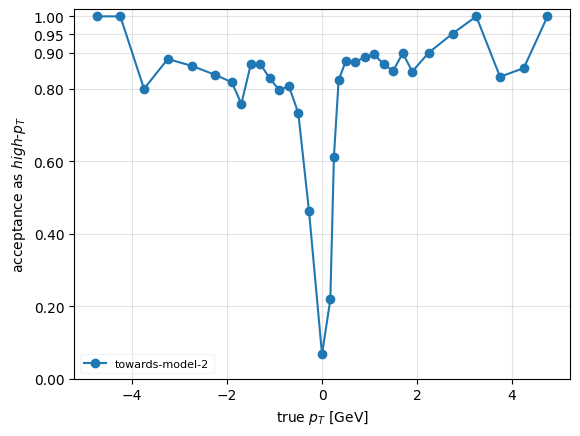

[DONE] Wrote outputs to: output


In [2]:
import torch
from tqdm import tqdm
from typing import Dict, List
from pathlib import Path
from models import registry
from dataloader import create_dataloaders
from utils import true_class_from_signed_pt, confusion_matrix_3, roc_curve_binary, auc_trapz
from plotting import plot_confusion, plot_roc, plot_prob_vs_pt, plot_acceptance_vs_pt
import numpy as np

MODEL_PATHS = ["output/best_model.pth"]

device = "cpu"
outdir = Path("output")

def load_model(path: str) -> torch.nn.Module:
    return torch.load(path, map_location=device, weights_only=False)

data = {}
# for model in [m1, m2, m3]:
for model_path in MODEL_PATHS:

    print(f"\n[INFO] Loading model from {model_path}...")

    model = load_model(model_path).to(device)

    model_name, model_cfg = registry.class_to_config(type(model))

    input_type = model_cfg["input_type"]

    print(f"\n[INFO] Evaluating {model_name} with input_type={input_type}...")

    _, _, test_loader = create_dataloaders(
        config_path="config/baseline.yml",
        batch_size=128,
        shuffle=False,
        input_type=input_type,
        target_type="raw",  # return raw labels for most flexibility in evaluation
        val_size=0.0,
        apply_scaling=True,
    )

    label_names = test_loader.dataset.label_names

    print(f"label_names: {label_names}")

    pt_idx = label_names.index("pt")

    true_pts, logits = [], []
    with torch.no_grad():
        for i, (x, y) in enumerate(tqdm(test_loader)):
            x = x.to(device)
            out = model(x)
            logits.append(out)
            true_pts.append(y[:, pt_idx])
            if i >= 1000:  # Limit to first 100 batches for quick evaluation
                break

    true_pts = np.concatenate(true_pts, axis=0)
    logits = torch.cat(logits, dim=0)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    pred_classes = np.argmax(probs, axis=1).astype(np.int8)
    true_classes = true_class_from_signed_pt(true_pts, pt_boundary=2.0)
    high_true = (true_classes == 2).astype(np.int32)

    data[model_name] = {
        "true_pts": true_pts,
        "logits": logits,
        "probs": probs,
        "pred_classes": pred_classes,
        "true_classes": true_classes,
        "high_true": high_true,
    }

p_high = {name: d["probs"][:, 2].astype(np.float32) for name, d in data.items()}

cm_by_model = {name: confusion_matrix_3(d["true_classes"], d["pred_classes"]) for name, d in data.items()}

rocs = {}
for name, ph in p_high.items():
    fpr, tpr = roc_curve_binary(high_true, ph)
    auc = auc_trapz(fpr, tpr)
    rocs[name] = (fpr, tpr, auc)

for name, cm in cm_by_model.items():
    acc = float(np.trace(cm) / max(cm.sum(), 1))
    print(f"[METRIC] {name} accuracy: {acc:.6f}")
for name, (_, _, auc) in rocs.items():
    print(f"[METRIC] {name} high-vs-low AUC: {auc:.6f}")

plot_confusion(cm_by_model, outdir / "confusion_matrices.png")
plot_roc(rocs, outdir / "roc_highpt.png")
plot_prob_vs_pt(true_pts, p_high, outdir / "pt_confidence_vs_true_pt.png", nbins=40)

plot_acceptance_vs_pt(true_pts, {name: data[name]["pred_classes"] for name in data.keys()}, outdir / "acceptance_vs_true_pt.png")

print("[DONE] Wrote outputs to:", str(outdir))    